In [180]:
# importing the required library
import pandas as pd
import numpy as np


In [181]:
# loading dataset
data=pd.read_csv("pima_indians_diabetes.csv")
data.sample(10)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetespedigreeFunction,Age,Outcome
742,1,109,58,18,116,28.5,0.219,22,0
94,2,142,82,18,64,24.7,0.761,21,0
125,1,88,30,42,99,55.0,0.496,26,1
755,1,128,88,39,110,36.5,1.057,37,1
25,10,125,70,26,115,31.1,0.205,41,1
390,1,100,66,29,196,32.0,0.444,42,0
123,5,132,80,0,0,26.8,0.186,69,0
671,1,99,58,10,0,25.4,0.551,21,0
103,1,81,72,18,40,26.6,0.283,24,0
539,3,129,92,49,155,36.4,0.968,32,1


Section 1 — Data Understanding (Q1–Q8)

Q1. What is the shape of the dataset — how many rows and columns does it have?

In [182]:
data.shape

(768, 9)

it have 768 rows and 9 columns

Q2. What are all the column names and what does each column medically represent in plain English?


In [183]:
data.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetespedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

Each columns represent the following medicall condition:-

Pregnancies = Number of times pregnant

Glucose = Plasma glucose concentration a 2 hours in an oral glucose tolerance test

BloodPressure = Diastolic blood pressure (mm Hg)

SkinThickness =  physical measurement used to estimate body fat percentage and overall nutritional status(mm)

Insulin = 2-Hour serum insulin (mu U/ml)

BMI = Body mass index (weight in kg/(height in m)^2)

DiabetesPedigreeFunction = score that estimates a person's risk of developing diabetes based on their genetic family history

Age = Age (years)

Outcome = Class variable (0 or 1) 268 of 768 are 1, the others are 0

Q3. What are the data types of each column — are they appropriate for analysis?


In [184]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetespedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


all the columns have numerical data so they are appropriate for analysis

Q4. What are the basic statistics — mean, median, min, max, and standard deviation of every column?


In [185]:
data.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetespedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


Q5. How many patients are diabetic (Outcome=1) vs non-diabetic (Outcome=0) — what is the percentage of each?

In [186]:
data['Outcome'].value_counts()


Outcome
0    500
1    268
Name: count, dtype: int64

diabetic patients= 268 and Non diabetic patients=500

In [187]:
# to see the data into percentage 
# normalize = Ture means (value count/total number of row)
(data['Outcome'].value_counts(normalize=True)*100).round(2).map("{:.2f}%".format)

Outcome
0    65.10%
1    34.90%
Name: proportion, dtype: object

65.10% are diabetic patients and 34.90% are diabetic patients

Q6. Are there any NaN missing values in the dataset?

In [188]:
data.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetespedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

No, there are no missing values in any column.

Q7. Are there any duplicate rows in the dataset?


In [189]:
data.duplicated().sum()

np.int64(0)

No, there are no any duplicate data

Q8. What is the age range of patients — what is the youngest, oldest, and average age?

In [190]:
youngest_patient_age=data['Age'].min()
oldest_patient_age=data['Age'].max()
average_age=data['Age'].mean().round(2)
print(f"Youngest Patient Age = {youngest_patient_age}, Oldest Patient Age = {oldest_patient_age}, Average Patient Age = {average_age}")

Youngest Patient Age = 21, Oldest Patient Age = 81, Average Patient Age = 33.24


Section 2 — Data Cleaning (Q9–Q16)

Q9. Count how many zero values exist in each column — which columns have medically impossible zeros where 0 cannot exist in real life?

In [191]:
(data==0).sum()

Pregnancies                 111
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetespedigreeFunction      0
Age                           0
Outcome                     500
dtype: int64

Glucose, BloodPressure, SkinThickness, Insulin, BMI columns have medically impossible zero values where O can't exist in real life:-


Q10. Replace all medically impossible zero values in Glucose, BloodPressure, SkinThickness, Insulin, and BMI with NaN — keep Pregnancies zeros as they are valid


In [192]:
data['Glucose']=data['Glucose'].replace(0,np.nan)
data['BloodPressure']=data['BloodPressure'].replace(0,np.nan)
data['SkinThickness']=data['SkinThickness'].replace(0,np.nan)
data['Insulin']=data['Insulin'].replace(0,np.nan)
data['BMI']=data['BMI'].replace(0,np.nan)

Q11. After replacing zeros with NaN — how many actual missing values does each column now have? Show as both count and percentage.

In [193]:
data.isnull().sum()

Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetespedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

In [194]:
missing_count=data.isnull().sum()
missing_percent=(data.isnull().sum()/len(data)*100).round(2)
missing_data = pd.DataFrame({
    "Missing Count": missing_count,
    "Missing Pecentage": missing_percent.map("{:.2f}%".format)
})
print(missing_data)

                          Missing Count Missing Pecentage
Pregnancies                           0             0.00%
Glucose                               5             0.65%
BloodPressure                        35             4.56%
SkinThickness                       227            29.56%
Insulin                             374            48.70%
BMI                                  11             1.43%
DiabetespedigreeFunction              0             0.00%
Age                                   0             0.00%
Outcome                               0             0.00%


Q12. Fill all missing values using median imputation — why is median better than mean for this medical data?

In [195]:
data.isnull().sum()

Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetespedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

In [196]:
Glucose_median=data['Glucose'].median()
data['Glucose']=data['Glucose'].replace(np.nan,Glucose_median)

BloodPressure_median=data['BloodPressure'].median()
data['BloodPressure']=data['BloodPressure'].replace(np.nan,BloodPressure_median)

SkinThickness_median=data['SkinThickness'].median()
data['SkinThickness']=data['SkinThickness'].replace(np.nan,SkinThickness_median)

Insulin_median=data['Insulin'].median()
data['Insulin']=data['Insulin'].replace(np.nan,Insulin_median)

BMI_median=data['BMI'].median()
data['BMI']=data['BMI'].replace(np.nan,BMI_median)


median is better then mean in medical data because median is not affected by the extreme outliers but the mean values are affected due to the extreme outliers

In [197]:
data.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetespedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Q13. Detect outliers in the Insulin column using the IQR method — how many outlier values exist?

In [198]:
# Calculate Q1 (25th percentile) and Q3 (75th percentile)
q1 = data['Insulin'].quantile(0.25)
q3 = data['Insulin'].quantile(0.75)

# calculate the IQR (Inter Quantile Range)
IQR = q3-q1

# Define outlier boundaries
lower_bound = q1-1.5*IQR
upper_bound = q3+1.5*IQR

# filtering the rows containing outliers
outliers = data[(data['Insulin']<lower_bound) | (data['Insulin']>upper_bound)]
print(len(outliers))


346


346 outliers values exist in Insulin column


Q14. Check for patients with Pregnancies greater than 15 — how many are there and are they diabetic?

In [199]:
data[data['Pregnancies']>15]

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetespedigreeFunction,Age,Outcome
159,17,163.0,72.0,41.0,114.0,40.9,0.817,47,1


there is only one patient with pragnancies count greaten then 15 and she is diabetic

Q15. Create a new column called BMI_Category using these medical thresholds — Underweight below 18.5, Normal 18.5 to 24.9, Overweight 25 to 29.9, Obese 30 and above. How many patients fall in each category?

In [200]:
# underweight=data[data['BMI']<18.5]
# normal=data[(data['BMI']>18.5) | (data['BMI']<24.9)]
# overweight=data[(data['BMI']>25) | (data['BMI']<29.9)]
# obese=data[(data['BMI']>=30)]

# dataFrame.loc[condition, 'Column_Name'] = 'Value'
data.loc[data['BMI']<18.5,'BMI_Category'] = 'underweight'
data.loc[((data['BMI']>=18.5)  & (data['BMI']<=24.9)),'BMI_Category'] = 'normal'
data.loc[((data['BMI']>=25) & (data['BMI']<=29.9)),'BMI_Category'] = 'overweight'
data.loc[(data['BMI']>=30),'BMI_Category'] = 'obese'
data

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetespedigreeFunction,Age,Outcome,BMI_Category
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50,1,obese
1,1,85.0,66.0,29.0,125.0,26.6,0.351,31,0,overweight
2,8,183.0,64.0,29.0,125.0,23.3,0.672,32,1,normal
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0,overweight
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1,obese
...,...,...,...,...,...,...,...,...,...,...
763,10,101.0,76.0,48.0,180.0,32.9,0.171,63,0,obese
764,2,122.0,70.0,27.0,125.0,36.8,0.340,27,0,obese
765,5,121.0,72.0,23.0,112.0,26.2,0.245,30,0,overweight
766,1,126.0,60.0,29.0,125.0,30.1,0.349,47,1,obese


In [201]:
data['BMI_Category'].value_counts()

BMI_Category
obese          483
overweight     179
normal         102
underweight      4
Name: count, dtype: int64

Q16. Create a new column called Age_Group — Young for ages 21 to 30, Middle for 31 to 45, Senior for 46 and above. How many diabetic patients are in each group?

In [202]:
data.loc[((data['Age']>=21) & (data['Age']<=30)),'Age_Group'] = 'Young'
data.loc[((data['Age']>=31) & (data['Age']<=45)),'Age_Group'] = 'Middle'
data.loc[(data['Age']>=46),'Age_Group'] = 'Senior'

In [203]:
data.groupby('Age_Group')['Outcome'].value_counts()

Age_Group  Outcome
Middle     1          120
           0          113
Senior     0           60
           1           58
Young      0          327
           1           90
Name: count, dtype: int64

so 120 middle aged patient, 58 Senior aged patiend and 90 young aged patient have diabetic

In [204]:
# another way to do the same
pd.crosstab(data['Age_Group'],data['Outcome'])

Outcome,0,1
Age_Group,,
Middle,113,120
Senior,60,58
Young,327,90


Section 3 — Data Manipulation (Q17–Q24)

Q17. Compare the mean values of ALL features between diabetic and non-diabetic patients — which features show the biggest difference?

In [205]:
data.groupby('Outcome').mean(numeric_only=True)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetespedigreeFunction,Age
Outcome,,,,,,,,
0,3.298000,110.682000,70.920000,27.726000,127.792000,30.885600,0.429734,31.190000
1,4.865672,142.130597,75.123134,31.686567,164.701493,35.383582,0.550500,37.067164


the Insulin shows the highest difference of about 36 then Glucose shows highest about 31

Q18. Filter the dataset to show only high-risk patients who have Glucose above 140 AND BMI above 30 — what percentage of these patients are actually diabetic?

In [206]:
high_risk_patients=data[(data['Glucose']>140) & (data['BMI']>30)]

print(len(high_risk_patients),"total high risk patient") # total high risk patient

print(((high_risk_patients['Outcome']==1).sum()),"total high risk patient with diabetic") # total high risk patient with diabetic

result = (((high_risk_patients['Outcome']==1).sum()) / (len(high_risk_patients)) * 100).round(2)
print(f"{result}% of high risk patient are actually diabetic")

148 total high risk patient
112 total high risk patient with diabetic
75.68% of high risk patient are actually diabetic


Q19. Calculate the diabetes rate for each Age Group — which age group has the highest diabetes percentage?

In [207]:
data['Age_Group'].value_counts()

Age_Group
Young     417
Middle    233
Senior    118
Name: count, dtype: int64

In [208]:
# for Young Age Group 
young_diabetic = len(data[(data['Age_Group']=='Young') & (data['Outcome']==1)]) # total young diabetic 
total_young = len(data[data['Age_Group']=='Young']) # total young age group
print(f"Young diabetic % = {((young_diabetic / total_young) * 100):.2f}")

# for Middle Age Group
middle_diabetic = len(data[(data['Age_Group']=='Middle') & (data['Outcome']==1)]) 
total_middle = len(data[data['Age_Group']=='Middle'])
print(f"Middle diabetic % = {((middle_diabetic/total_middle)*100):.2f}")

# for Senior Age Group
senior_diabetic = len(data[(data['Age_Group']=='Senior') & (data['Outcome']==1)]) 
total_senior = len(data[data['Age_Group']=='Senior']) 
print(f"Senior diabetic % = {((senior_diabetic/total_senior)*100):.2f}")

Young diabetic % = 21.58
Middle diabetic % = 51.50
Senior diabetic % = 49.15


middle age group have the highest diabetic percentage i.e 51.5%

Q20. Calculate the diabetes rate by BMI Category — does Obese always mean higher diabetes risk compared to Normal weight?

In [209]:
data['BMI_Category'].value_counts()

BMI_Category
obese          483
overweight     179
normal         102
underweight      4
Name: count, dtype: int64

In [210]:
# for obese BMI Category
obese_diabetic=len(data[(data['BMI_Category']=='obese') & (data['Outcome']==1)])
total_obese=len(data[data['BMI_Category']=='obese'])
obese_diabetic_rate=(obese_diabetic/total_obese)*100
print(f" obese diabetic rate = {(obese_diabetic_rate):.2f}%")

# for overweight BMI Category
overweight_diabetic=len(data[(data['BMI_Category']=='overweight') & (data['Outcome']==1)])
total_overweight=len(data[data['BMI_Category']=='overweight'])
overweight_diabetic_rate=(overweight_diabetic/total_overweight)*100
print(f" over weight diabetic rate = {(overweight_diabetic_rate):.2f}%")

# for Normal BMI Category
normal_diabetic=len(data[(data['BMI_Category']=='normal') & (data['Outcome']==1)])
total_normal=len(data[data['BMI_Category']=='normal'])
normal_diabetic_rate=(normal_diabetic/total_normal)*100
print(f" normal diabetic rate = {(normal_diabetic_rate):.2f}%")

#for underweight BMI Category
underweight_diabetic=len(data[(data['BMI_Category']=='underweight') & (data['Outcome']==1)])
total_underweight=len(data[data['BMI_Category']=='underweight'])
underweight_diabetic_rate=(underweight_diabetic/total_underweight)*100
print(f" under weight diabetic rate = {(underweight_diabetic_rate):.2f}%")

 obese diabetic rate = 45.76%
 over weight diabetic rate = 22.35%
 normal diabetic rate = 6.86%
 under weight diabetic rate = 0.00%


Yes, Obese always mean higher diabetes risk compared to Normal weight.

Q21. Create a Glucose_Risk column using real medical thresholds — Normal below 100, Prediabetic 100 to 125, Diabetic Range 126 and above. What percentage of patients in each risk level are actually diabetic?


In [211]:
# dataFrame.loc[condition, 'Column_Name'] = 'Value'
data.loc[(data['Glucose']<100),'Glucose_Risk'] = 'Normal'
data.loc[((data['Glucose']>=100) & (data['Glucose']<=125)),'Glucose_Risk'] = 'Prediabetic'
data.loc[(data['Glucose']>=126),'Glucose_Risk'] = 'Diabetic'

data['Glucose_Risk'].value_counts()

Glucose_Risk
Diabetic       297
Prediabetic    279
Normal         192
Name: count, dtype: int64

In [212]:
Diabetic_rate=(len(data[(data['Glucose_Risk']=='Diabetic') & (data['Outcome']==1)]) / len(data[data['Glucose_Risk']=='Diabetic']))*100
print(f"{(Diabetic_rate):.2f}% of patient in Diabetic Risk level are actually diabetic")

Prediabetic_rate=(len(data[(data['Glucose_Risk']=='Prediabetic') & (data['Outcome']==1)]) / len(data[data['Glucose_Risk']=='Prediabetic']))*100
print(f"{(Prediabetic_rate):.2f}% of patient in Prediabetic Risk level are actually diabetic")

Normal_rate=(len(data[(data['Glucose_Risk']=='Normal') & (data['Outcome']==1)]) / len(data[data['Glucose_Risk']=='Normal']))*100
print(f"{(Normal_rate):.2f}% of patient in Normal Risk level are actually diabetic")

59.26% of patient in Diabetic Risk level are actually diabetic
27.96% of patient in Prediabetic Risk level are actually diabetic
7.29% of patient in Normal Risk level are actually diabetic


Q22. Find the top 10 patients with the highest Glucose levels — show their Glucose, BMI, Age, and Outcome. Are they all diabetic?

In [213]:
data.sort_values(by='Glucose', ascending=False).head(10)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetespedigreeFunction,Age,Outcome,BMI_Category,Age_Group,Glucose_Risk
661,1,199.0,76.0,43.0,125.0,42.9,1.394,22,1,obese,Young,Diabetic
561,0,198.0,66.0,32.0,274.0,41.3,0.502,28,1,obese,Young,Diabetic
228,4,197.0,70.0,39.0,744.0,36.7,2.329,31,0,obese,Middle,Diabetic
8,2,197.0,70.0,45.0,543.0,30.5,0.158,53,1,obese,Senior,Diabetic
579,2,197.0,70.0,99.0,125.0,34.7,0.575,62,1,obese,Senior,Diabetic
408,8,197.0,74.0,29.0,125.0,25.9,1.191,39,1,overweight,Middle,Diabetic
359,1,196.0,76.0,36.0,249.0,36.5,0.875,29,1,obese,Young,Diabetic
22,7,196.0,90.0,29.0,125.0,39.8,0.451,41,1,obese,Middle,Diabetic
206,8,196.0,76.0,29.0,280.0,37.5,0.605,57,1,obese,Senior,Diabetic
675,6,195.0,70.0,29.0,125.0,30.9,0.328,31,1,obese,Middle,Diabetic


In top 10 patitents with the highest Glucose Level only one patient is not diabetic

Q23. Calculate the correlation of every feature with Outcome — rank them from strongest to weakest predictor of diabetes.

In [214]:
# data.corr(numeric_only=True) -> this code gives the matrix of all columns vs all columns
# data.corr(numeric_only=Ture)['Outcome']  -> this code gives matrix of all columns vs Outcome column
data.corr(numeric_only=True)['Outcome'].drop('Outcome').sort_values(ascending=False)

Glucose                     0.492782
BMI                         0.312038
Age                         0.238356
Pregnancies                 0.221898
SkinThickness               0.214873
Insulin                     0.203790
DiabetespedigreeFunction    0.173844
BloodPressure               0.165723
Name: Outcome, dtype: float64

Q24. What is the average number of pregnancies for diabetic vs non-diabetic patients — does having more pregnancies increase diabetes risk?

In [223]:
data.groupby('Outcome')['Pregnancies'].mean().round(2)

Outcome
0    3.30
1    4.87
Name: Pregnancies, dtype: float64

Non-diabetic average number of pregnancies = 3.30

diabetic average number of pregnancies = 4.87 

it clearly shows that patient with higher number of pregnencies are diabetic

Section 4 — Visualization with Seaborn (Q25–Q35)

Q25. Plot a countplot showing the number of diabetic vs non-diabetic patients — add percentage labels on each bar.

In [226]:
import seaborn as sns
import matplotlib.pyplot as plt



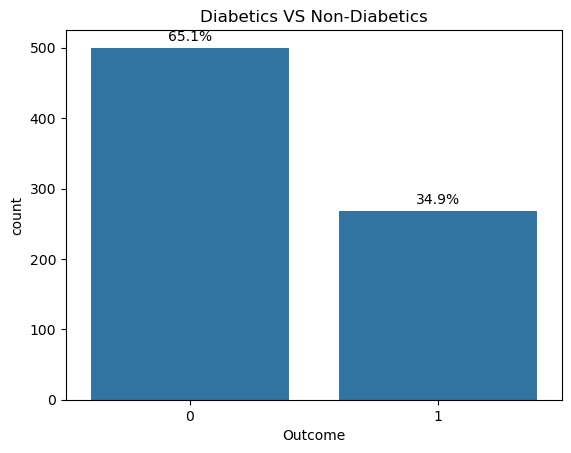

In [252]:
sns.countplot(data=data, x='Outcome')
plt.title("Diabetics VS Non-Diabetics")

percentages = data['Outcome'].value_counts(normalize=True) * 100

# 3. Format them as strings with a '%' sign
pct_labels = [f'{p:.1f}%' for p in percentages]

# 4. Put them on the bars
plt.bar_label(plt.gca().containers[0], labels=pct_labels, padding=3)
plt.show()

Q26. Plot histograms for all 8 numerical features in a single figure — what is the distribution shape of each? Is Insulin skewed?

In [270]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    float64
 2   BloodPressure             768 non-null    float64
 3   SkinThickness             768 non-null    float64
 4   Insulin                   768 non-null    float64
 5   BMI                       768 non-null    float64
 6   DiabetespedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
 9   BMI_Category              768 non-null    object 
 10  Age_Group                 768 non-null    object 
 11  Glucose_Risk              768 non-null    object 
dtypes: float64(6), int64(3), object(3)
memory usage: 72.1+ KB


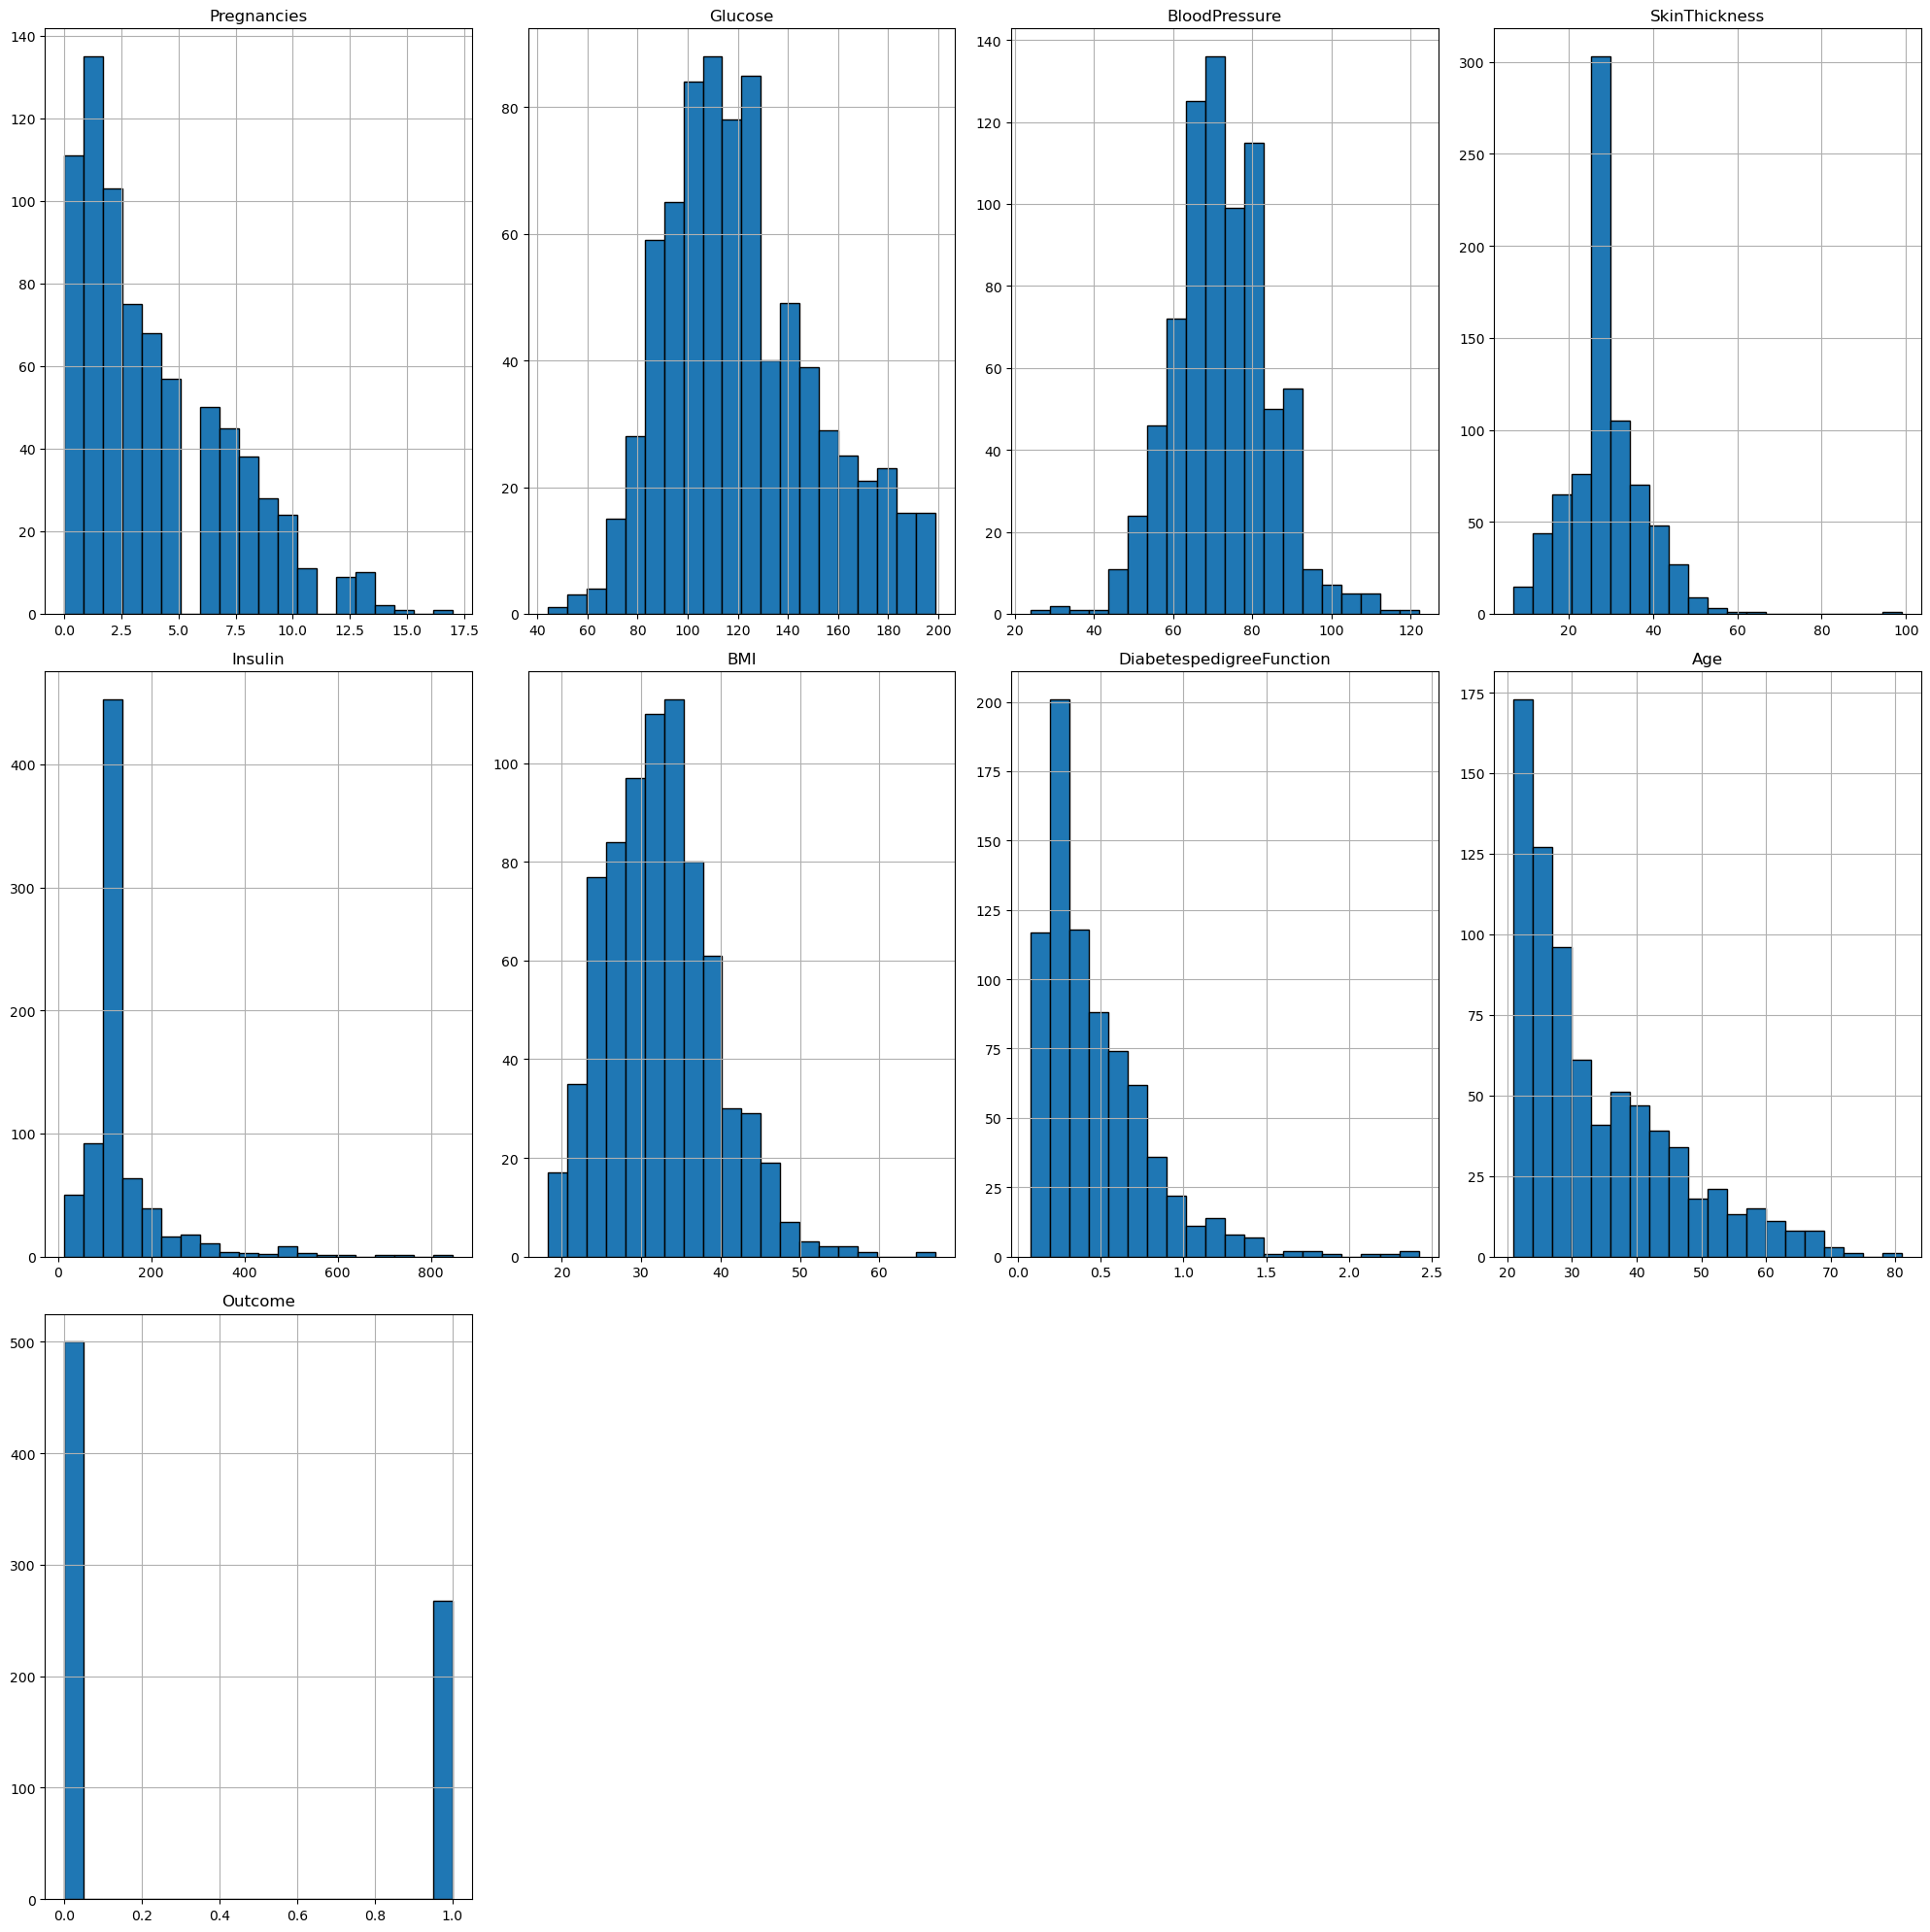

In [271]:
numerical_features = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 
                      'Insulin', 'BMI', 'DiabetespedigreeFunction', 'Age', 'Outcome']

# Plot all histograms in a 2x4 grid layout
data[numerical_features].hist(bins=20, figsize=(20, 20), layout=(3, 4), edgecolor='black')

# Adjust layout so labels don't overlap
plt.tight_layout()
plt.show()